# SET 9. Анализ алгоритмов сортировки строк
АиСД 2025/26

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = pd.read_csv('results.csv')

# стандартные алгоритмы
STD_STYLE = {
    'StdMergeSort': {'color': '#e74c3c', 'ls': '-',  'label': 'MergeSort'},
    'StdQuickSort': {'color': '#e67e22', 'ls': '--', 'label': 'QuickSort'},
}

# адаптированные алгоритмы
STR_STYLE = {
    'StringMergeSort':    {'color': '#2980b9', 'ls': '-',  'label': 'String MergeSort'},
    'StringQuickSort':    {'color': '#27ae60', 'ls': '--', 'label': 'String QuickSort'},
    'MsdRadixSort':       {'color': '#8e44ad', 'ls': ':',  'label': 'MSD Radix'},
    'MsdRadixSortHybrid': {'color': '#16a085', 'ls': '-.', 'label': 'MSD Radix + Quick'},
}

TYPE_NAME = {
    'random':        'Случайный',
    'reverse':       'Обратно отсортированный',
    'nearly_sorted': 'Почти отсортированный',
}
TYPES = ['random', 'reverse', 'nearly_sorted']

print('Загружено строк:', len(df))
df.head()

Загружено строк: 540


,algorithm,array_type,array_size,time_us,char_cmp
0,StdMergeSort,random,100,239.7,610
1,StdQuickSort,random,100,34.4,663
2,StringMergeSort,random,100,315.4,1293
3,StringQuickSort,random,100,17.3,581
4,MsdRadixSort,random,100,229.3,187


## 1. Стандартные алгоритмы: время и сравнения

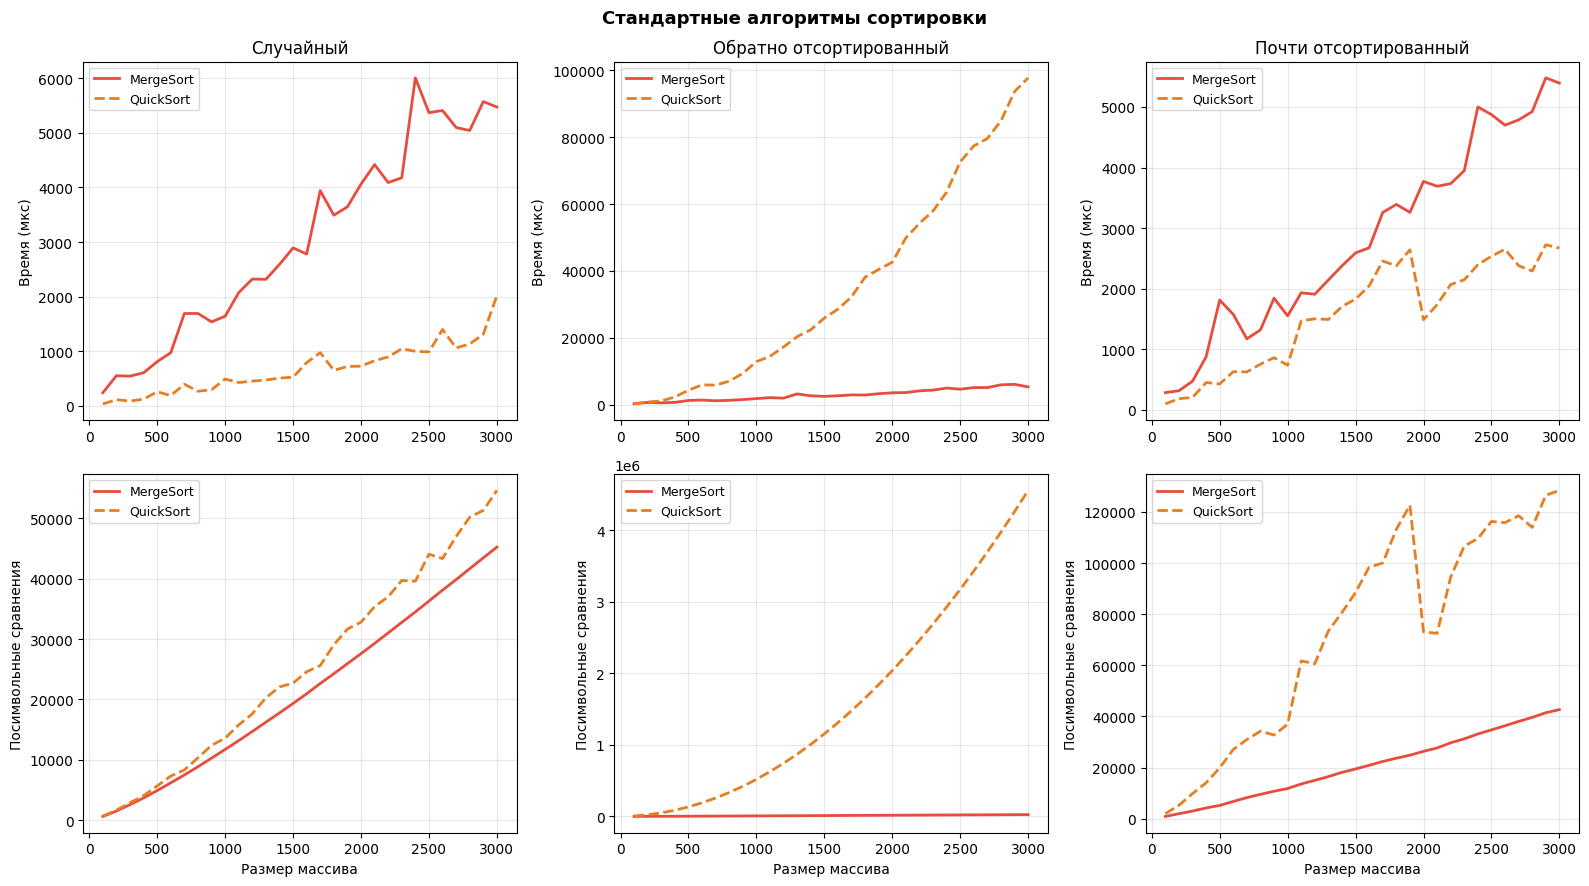

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Стандартные алгоритмы сортировки', fontsize=13, fontweight='bold')

for col, arr_type in enumerate(TYPES):
    sub = df[df['array_type'] == arr_type]
    for algo, s in STD_STYLE.items():
        data = sub[sub['algorithm'] == algo].sort_values('array_size')
        axes[0][col].plot(data['array_size'], data['time_us'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=2)
        axes[1][col].plot(data['array_size'], data['char_cmp'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=2)

    axes[0][col].set_title(TYPE_NAME[arr_type])
    axes[0][col].set_ylabel('Время (мкс)')
    axes[0][col].grid(True, alpha=0.3)
    axes[0][col].legend(fontsize=9)

    axes[1][col].set_xlabel('Размер массива')
    axes[1][col].set_ylabel('Посимвольные сравнения')
    axes[1][col].grid(True, alpha=0.3)
    axes[1][col].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Вывод:**

 MergeSort значительно быстрее по времени на обратно отсортированных массивах, при этом на случайных и почти отсортированнных медленнее.

 MergeSort всегда делает меньше посимвольных сравнений на всех типах данных. Но если на случайных массивах разница не большая, то на обратно отсортированных в размерности (·10⁶) MergeSort остается около нуля а QuickSort быстро растет. На почти отсортированных массивах у QuickSort очень ломанная траектория количества посимвольных сравнений в то время как MergeSort достаточно стабилен.

 Основное наблюдение, что MergeSort сильно лучше на обратно отсортированных массивах.

## 2. Адаптированные алгоритмы: время и сравнения


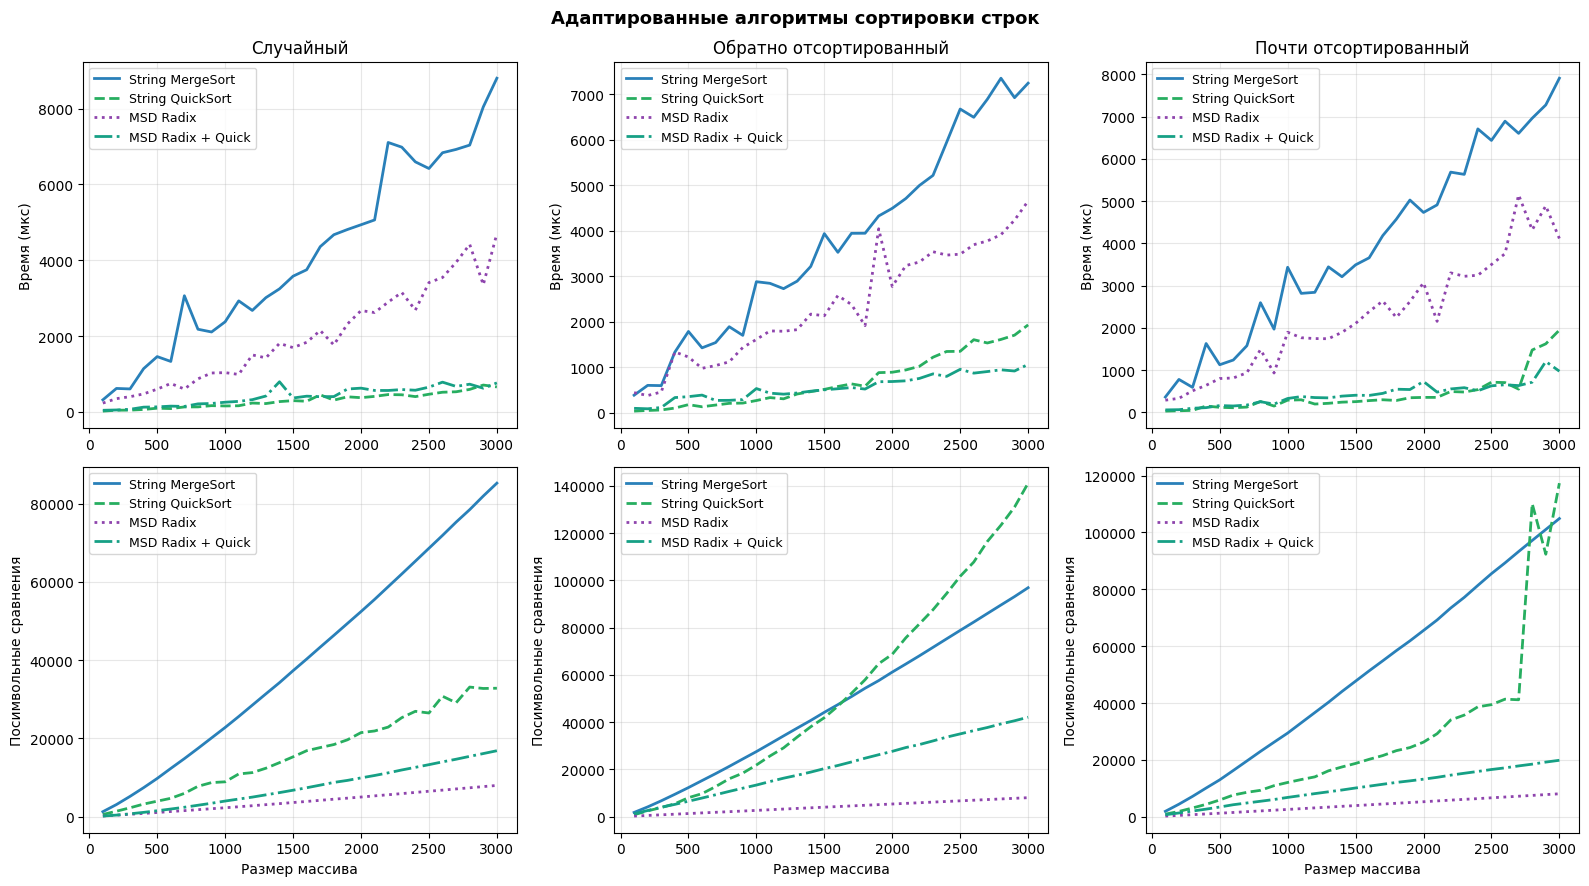

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Адаптированные алгоритмы сортировки строк', fontsize=13, fontweight='bold')

for col, arr_type in enumerate(TYPES):
    sub = df[df['array_type'] == arr_type]
    for algo, s in STR_STYLE.items():
        data = sub[sub['algorithm'] == algo].sort_values('array_size')
        axes[0][col].plot(data['array_size'], data['time_us'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=2)
        axes[1][col].plot(data['array_size'], data['char_cmp'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=2)

    axes[0][col].set_title(TYPE_NAME[arr_type])
    axes[0][col].set_ylabel('Время (мкс)')
    axes[0][col].grid(True, alpha=0.3)
    axes[0][col].legend(fontsize=9)

    axes[1][col].set_xlabel('Размер массива')
    axes[1][col].set_ylabel('Посимвольные сравнения')
    axes[1][col].grid(True, alpha=0.3)
    axes[1][col].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Вывод:**
String MergeSort оказался самым медленным среди адаптированных алгоритмов как по времени, так и в среднем по числу посимвольных сравнений.

MSD Radix Sort делает наименьшее число посимвольных сравнений на всех типах данных, что соответствует теоретической оценке O(DP(R) + n·log|Σ|), но по времени нестабилен и является вторым по медленности.

Гибрид MSD Radix+Quick совмещает преимущества обоих подходов и показывает почти лучшее время на всех данных, но по количеству сравнений немного уступает MSD Radix Sort.
  
String QuickSort ведёт себя предсказуемо на случайных данных, но на обратно отсортированных деградирует и по времени и по числу сравнений. Также он сильно ухудшается на почти отсортированных массивах при достижении размера ~2700 по обоим показателям.

## 3. Стандартные vs адаптированные

Прямое сравнение лучшего стандартного и лучшего адаптированного алгоритма по обеим метрикам на всех трёх типах данных.

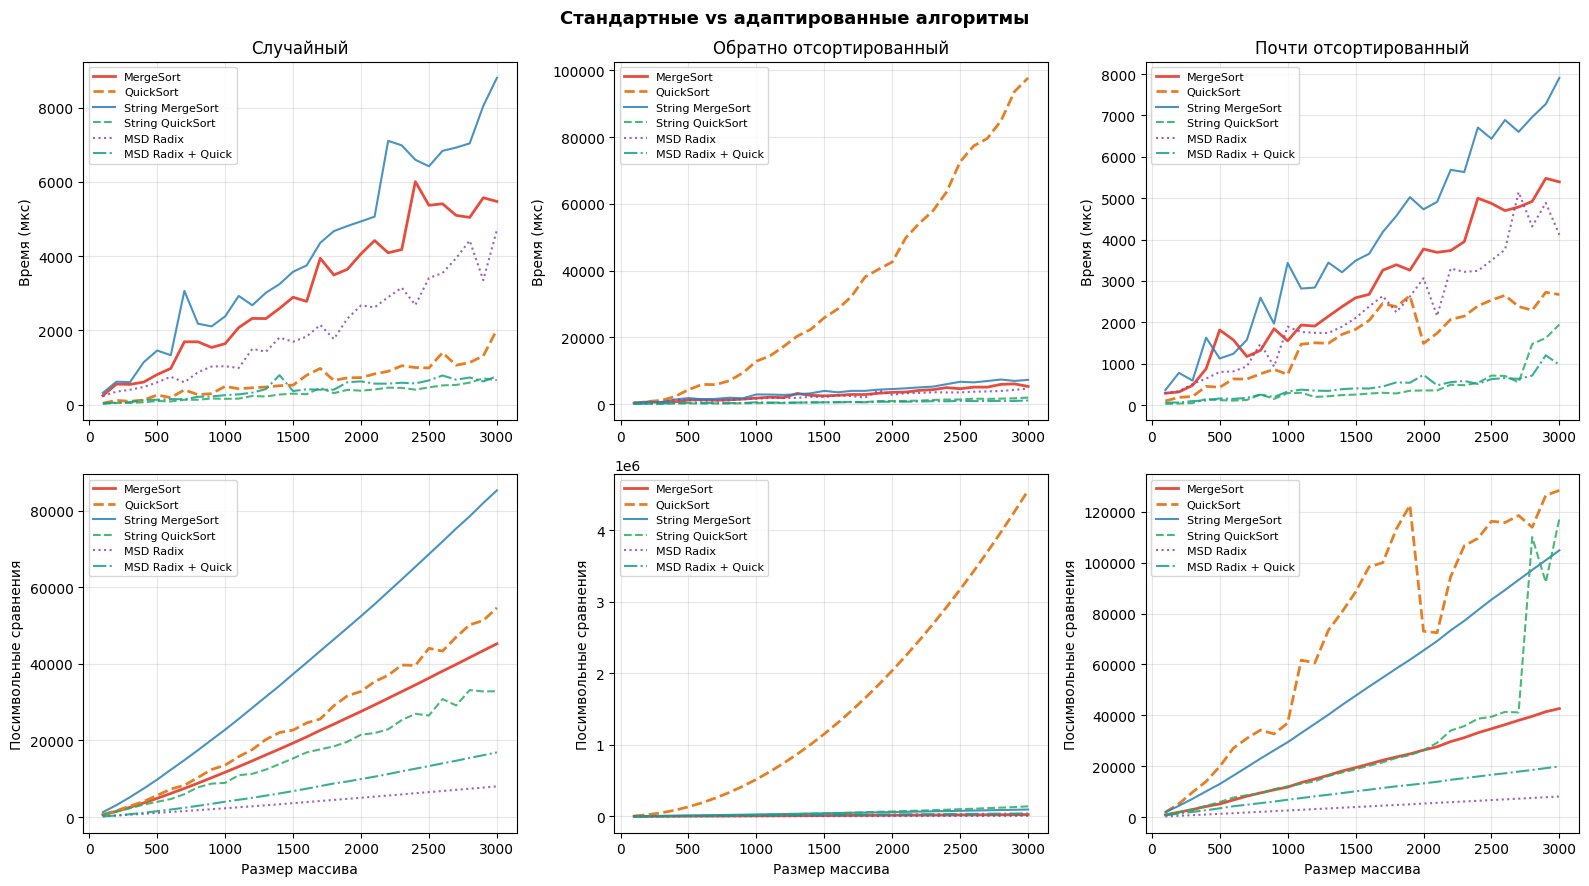

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Стандартные vs адаптированные алгоритмы', fontsize=13, fontweight='bold')

for col, arr_type in enumerate(TYPES):
    sub = df[df['array_type'] == arr_type]
    for algo, s in STD_STYLE.items():
        data = sub[sub['algorithm'] == algo].sort_values('array_size')
        axes[0][col].plot(data['array_size'], data['time_us'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=2)
        axes[1][col].plot(data['array_size'], data['char_cmp'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=2)
    for algo, s in STR_STYLE.items():
        data = sub[sub['algorithm'] == algo].sort_values('array_size')
        axes[0][col].plot(data['array_size'], data['time_us'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=1.5, alpha=0.85)
        axes[1][col].plot(data['array_size'], data['char_cmp'],
                          color=s['color'], ls=s['ls'], label=s['label'], lw=1.5, alpha=0.85)

    axes[0][col].set_title(TYPE_NAME[arr_type])
    axes[0][col].set_ylabel('Время (мкс)')
    axes[0][col].grid(True, alpha=0.3)
    axes[0][col].legend(fontsize=8)

    axes[1][col].set_xlabel('Размер массива')
    axes[1][col].set_ylabel('Посимвольные сравнения')
    axes[1][col].grid(True, alpha=0.3)
    axes[1][col].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Вывод:**

По времени на случайных данных стандартный MergeSort и String MergeSort оказались медленнее стандартного QuickSort - адаптация через LCP не дала выигрыша по скорости из-за накладных расходов на копирование. String QuickSort и MSD Radix+Quick работают быстрее всех остальных на случайных и почти отсортированных данных.

На обратно отсортированных данных: стандартный QuickSort деградирует до ~4·10⁶ посимвольных сравнений, тогда как все адаптированные алгоритмы остаются в пределах (0-1)·10⁶.

String MergeSort делает больше сравнений чем стандартный MergeSort на случайных и почти отсортированных данных.

MSD Radix Sort стабильно минимален по сравнениям на всех типах данных, что соответствует теории.

## 4. Сравнение с теоретической оценкой


Теоретические оценки числа посимвольных сравнений:
- **StdMergeSort** - $O(n \cdot \log n \cdot \log_{|\Sigma|} n)$
- **StdQuickSort** - $O(n^2 \cdot \log_{|\Sigma|} n)$ в худшем, $O(n \cdot \log n \cdot \log_{|\Sigma|} n)$ в среднем
- **StringMergeSort** - $O(DP(R) + n \cdot \log n)$
- **StringQuickSort** - $O(DP(R) + n \cdot \log n)$ (оптимальный)
- **MsdRadixSort** - $O(DP(R) + n \cdot \log |\Sigma|)$
- **MsdRadixSortHybrid** - $O(DP(R) + n \cdot \log |\Sigma|)$

Сравниваем форму кривых на случайных данных.


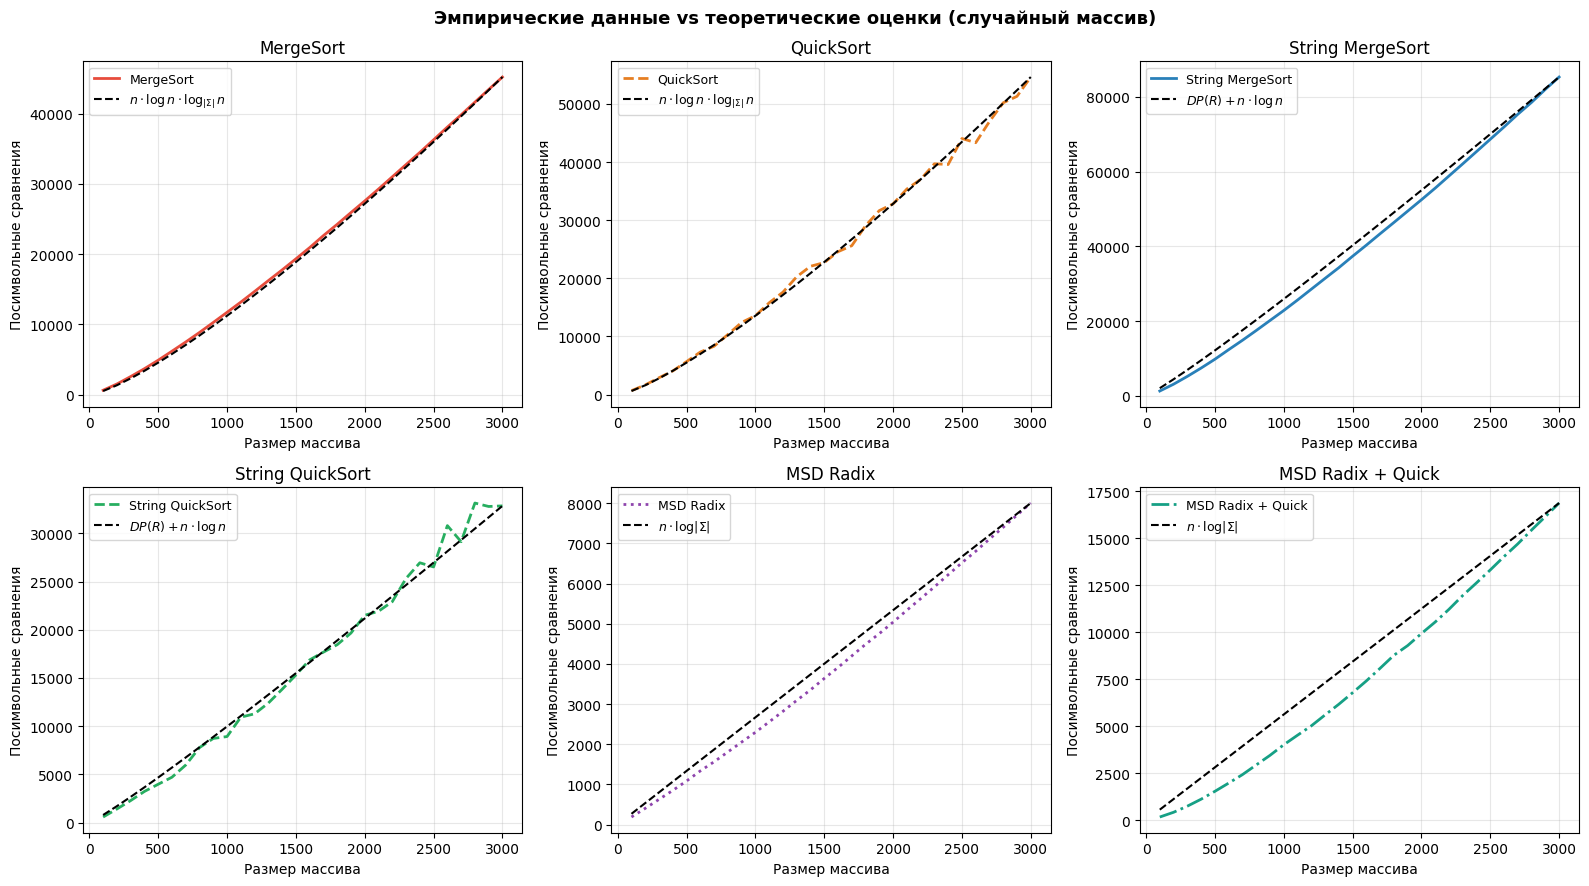

In [ ]:
sub = df[df['array_type'] == 'random']
sizes = np.array(sorted(df['array_size'].unique()))
SIGMA = 74

def scale(theory_curve, algo):
    emp_val = sub[sub['algorithm'] == algo].sort_values('array_size')['char_cmp'].values[-1]
    return theory_curve * (emp_val / theory_curve[-1])

# теоретические кривые для каждого алгоритма
theory = {
    'StdMergeSort':       sizes * np.log2(sizes) * np.log2(sizes) / np.log2(SIGMA),
    'StdQuickSort':       sizes * np.log2(sizes) * np.log2(sizes) / np.log2(SIGMA),
    'StringMergeSort':    sizes * np.log2(sizes) + sizes * np.log2(SIGMA),
    'StringQuickSort':    sizes * np.log2(sizes) + sizes * np.log2(SIGMA),
    'MsdRadixSort':       sizes * np.log2(SIGMA),
    'MsdRadixSortHybrid': sizes * np.log2(SIGMA),
}

theory_label = {
    'StdMergeSort':       r'$n \cdot \log n \cdot \log_{|\Sigma|}n$',
    'StdQuickSort':       r'$n \cdot \log n \cdot \log_{|\Sigma|}n$',
    'StringMergeSort':    r'$DP(R) + n \cdot \log n$',
    'StringQuickSort':    r'$DP(R) + n \cdot \log n$',
    'MsdRadixSort':       r'$n \cdot \log |\Sigma|$',
    'MsdRadixSortHybrid': r'$n \cdot \log |\Sigma|$',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Эмпирические данные vs теоретические оценки (случайный массив)',
             fontsize=13, fontweight='bold')

ALL_STYLE = {**STD_STYLE, **STR_STYLE}

for idx, (algo, s) in enumerate(ALL_STYLE.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row][col]

    data = sub[sub['algorithm'] == algo].sort_values('array_size')
    ax.plot(data['array_size'], data['char_cmp'],
            color=s['color'], ls=s['ls'], lw=2, label=s['label'])
    ax.plot(sizes, scale(theory[algo], algo),
            'k--', lw=1.5, label=theory_label[algo])

    ax.set_title(s['label'])
    ax.set_xlabel('Размер массива')
    ax.set_ylabel('Посимвольные сравнения')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:**

В целом теоретические и практические оценки совпадают, видны отклонения у алгоритмов String MergeSort, Msd Radix, Msd Radix + Quick они работают в среднем быстрее теоретической оценки.

У Quick Sort и адаптации сложность колеблется вокруг теоретической.

У Merge Sort почти идеально совпадает.